Import e percorsi

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

METADATA_PATH = (
    PROCESSED_DIR
    / "eccdna_metadata_clean.tsv"
)

FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)

print("Metadata:", METADATA_PATH.exists())
print("FASTA:", FASTA_PATH.exists())

Metadata: True
FASTA: True


Caricamento metadata

In [3]:
metadata = pd.read_csv(
    METADATA_PATH,
    sep="\t",
    low_memory=False
)

print("Shape:", metadata.shape)

metadata[
    [
        "id",
        "disease",
        "disease_clean",
        "length",
        "gc",
        "source_db",
        "split_cluster"
    ]
].head()

Shape: (3755079, 26)


,id,disease,disease_clean,length,gc,source_db,split_cluster
0,eccDNABase_000124402,Prostate Cancer,prostate cancer,209,0.669856,eccDNABase,train
1,CircleBaseV2_002758843,Healthy,healthy,228,0.609649,CircleBaseV2,train
2,eccDNABase_000575011,Health,healthy,227,0.607930,eccDNABase,train
3,CircleBaseV2_000063599,Gastric cancer,gastric cancer,684,0.576023,CircleBaseV2,train
4,eccDNABase_000124403,Prostate Cancer,prostate cancer,393,0.557252,eccDNABase,train


In [4]:
print(
    metadata["disease_clean"]
    .value_counts()
    .head(15)
)

disease_clean
gastric cancer                            2593291
healthy                                    445138
ovarian cancer                             172898
prostate cancer                            170297
colorectal cancer                           88639
lymphoma                                    69245
multiple diseases                           57482
hiv infectious disease                      42923
cervical adenocarcinoma                     38740
leukemia                                    24304
primary pulmonary hypertension               8119
cataract                                     8021
hypopharyngeal squamous cell carcinoma       5925
glioblastoma cancer                          5681
melanoma                                     4787
Name: count, dtype: int64


Scelta di un pilot per prova tecnica

In [5]:
PILOT_CLASSES = [
    "healthy",
    "gastric cancer",
    "ovarian cancer",
    "prostate cancer",
    "colorectal cancer"
]

N_PER_CLASS = 5
RANDOM_STATE = 42

In [6]:
pilot_parts = []

for disease in PILOT_CLASSES:

    subset = metadata[
        metadata["disease_clean"] == disease
    ]

    sampled = subset.sample(
        n=min(N_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE
    )

    pilot_parts.append(sampled)

pilot_metadata = pd.concat(
    pilot_parts,
    ignore_index=True
)

print("Numero sequenze pilot:", len(pilot_metadata))

pilot_metadata[
    ["id", "disease_clean", "length", "gc", "source_db"]
]

Numero sequenze pilot: 25


,id,disease_clean,length,gc,source_db
0,eccDNABase_000814839,healthy,216,0.449074,eccDNABase
1,eccDNABase_000677734,healthy,3320,0.460843,eccDNABase
2,eccDNABase_000716113,healthy,1329,0.404816,eccDNABase
3,eccDNABase_000699926,healthy,149,0.342282,eccDNABase
4,CircleBaseV2_002890355,healthy,158,0.373418,CircleBaseV2
5,CircleBaseV2_001106672,gastric cancer,396,0.472222,CircleBaseV2
6,CircleBaseV2_002582836,gastric cancer,382,0.518325,CircleBaseV2
7,CircleBaseV2_000323304,gastric cancer,2192,0.425639,CircleBaseV2
8,CircleBaseV2_002680587,gastric cancer,732,0.418033,CircleBaseV2
9,CircleBaseV2_002507600,gastric cancer,1031,0.371484,CircleBaseV2


# Recupero delle sequenze dal FASTA

Il file FASTA contiene le sequenze nucleotidiche associate agli identificativi presenti nel metadata.

Per il pilot dataset vengono recuperate esclusivamente le sequenze necessarie, evitando di caricare l'intero FASTA in memoria.

In [15]:
def load_fasta_sequences(fasta_path, target_ids):
    """
    Legge il FASTA e recupera solo le sequenze
    i cui ID sono presenti in target_ids.

    L'ID FASTA è la parte dell'header prima del primo "|".
    """

    target_ids = set(map(str, target_ids))

    sequences = {}

    current_id = None
    current_sequence = []

    with open(fasta_path, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                # Salva il record precedente
                if current_id is not None and current_id in target_ids:
                    sequences[current_id] = "".join(current_sequence)

                    # Se li abbiamo già trovati tutti, possiamo fermarci
                    if len(sequences) == len(target_ids):
                        break

                # Nuovo header
                header = line[1:]

                # IMPORTANTE:
                # >eccDNABase_000124402|label=1|...
                # diventa eccDNABase_000124402
                current_id = header.split("|", 1)[0].strip()

                current_sequence = []

            else:
                current_sequence.append(line)

        # Gestisce l'ultimo record
        if (
            current_id is not None
            and current_id in target_ids
            and current_id not in sequences
        ):
            sequences[current_id] = "".join(current_sequence)

    return sequences

In [17]:
pilot_ids = pilot_metadata["id"].tolist()

pilot_sequences = load_fasta_sequences(
    FASTA_PATH,
    pilot_ids
)

print(
    "Sequenze richieste:",
    len(pilot_ids)
)

print(
    "Sequenze trovate:",
    len(pilot_sequences)
)

Sequenze richieste: 25
Sequenze trovate: 25


In [18]:
missing_ids = set(pilot_ids) - set(pilot_sequences.keys())

print("Sequenze mancanti:", len(missing_ids))

if missing_ids:
    print(list(missing_ids)[:10])

Sequenze mancanti: 0


In [21]:
for seq_id in list(pilot_sequences.keys())[:5]:

    sequence = pilot_sequences[seq_id]

    disease = pilot_metadata.loc[
        pilot_metadata["id"] == seq_id,
        "disease_clean"
    ].iloc[0]

    print("ID:", seq_id)
    print("Disease:", disease)
    print("Length FASTA:", len(sequence))
    print("First 80 nt:", sequence[:80])
    print("-" * 80)

ID: eccDNABase_000333792
Disease: prostate cancer
Length FASTA: 694
First 80 nt: ACCCACTACATGGAGATGTTGGGAAGATTAAGTCAAATTAAGTATTAACTGCTTAAATATTCAGTTGAAAACAATTTATT
--------------------------------------------------------------------------------
ID: CircleBaseV2_002978263
Disease: colorectal cancer
Length FASTA: 712
First 80 nt: GGCCTTGCTCTGTCACCCGGGCTGGAGTGCAGTGGTGTGAACACAGCTCAAACACAGCTCACTACAGCCTTGACCTGCTG
--------------------------------------------------------------------------------
ID: eccDNABase_000677734
Disease: healthy
Length FASTA: 3320
First 80 nt: CACCATGGCACATGTATGCCTCTGTAACAAAACTGCACGTTCTGCACATGTGTCCCAGAATTTAAAGTGAAATAAAATAA
--------------------------------------------------------------------------------
ID: eccDNABase_000392422
Disease: prostate cancer
Length FASTA: 335
First 80 nt: GCTGGGTGGGGGGCTGGCTGCTGTGTGGCTCTCTCTGGAGCCACCCTCCTGGTCCAGGGAAGTGACTCTCACACCCTGAG
--------------------------------------------------------------------------------
ID: CircleBaseV2_002914075
Dise

# Controllo delle sequenze

Prima della generazione delle FCGR vengono controllate la lunghezza delle sequenze e la presenza di caratteri non appartenenti all'alfabeto canonico A/C/G/T.

In [19]:
VALID_BASES = set("ACGT")

sequence_check = []

for seq_id, seq in pilot_sequences.items():

    seq = seq.upper()

    invalid_bases = set(seq) - VALID_BASES

    sequence_check.append({
        "id": seq_id,
        "length_fasta": len(seq),
        "invalid_bases": "".join(
            sorted(invalid_bases)
        )
    })

sequence_check = pd.DataFrame(sequence_check)

sequence_check.head()

,id,length_fasta,invalid_bases
0,eccDNABase_000333792,694,
1,CircleBaseV2_002978263,712,
2,eccDNABase_000677734,3320,
3,eccDNABase_000392422,335,
4,CircleBaseV2_002914075,1080,


In [22]:
print(
    "Sequenze con basi non canoniche:",
    (sequence_check["invalid_bases"] != "").sum()
)

print(
    "Lunghezza minima:",
    sequence_check["length_fasta"].min()
)

print(
    "Lunghezza massima:",
    sequence_check["length_fasta"].max()
)

Sequenze con basi non canoniche: 0
Lunghezza minima: 114
Lunghezza massima: 3320


# Generazione della FCGR

Per ogni sequenza vengono estratti tutti i k-mer validi. Ogni k-mer viene
mappato nello spazio CGR mediante l'algoritmo iterativo del punto medio,
utilizzando i quattro vertici associati alle basi A, C, G e T.

La posizione CGR finale del k-mer viene discretizzata nella matrice FCGR
di dimensione `2^k × 2^k`, che contiene quindi i conteggi delle occorrenze
dei diversi k-mer.

In [29]:
def compute_fcgr(sequence, k):
    """
    Calcola una Frequency Chaos Game Representation (FCGR)
    usando la convenzione CGR del progetto originale.

    Vertici:
        A = (0, 1)
        T = (1, 1)
        C = (0, 0)
        G = (1, 0)
    """

    sequence = sequence.upper()

    size = 2 ** k

    fcgr_counts = np.zeros(
        (size, size),
        dtype=np.int32
    )

    corners = {
        "A": (0.0, 1.0),
        "C": (0.0, 0.0),
        "G": (1.0, 0.0),
        "T": (1.0, 1.0)
    }

    valid_kmers = 0

    for i in range(len(sequence) - k + 1):

        kmer = sequence[i:i + k]

        if any(base not in corners for base in kmer):
            continue

        # Punto iniziale del CGR
        x = 0.5
        y = 0.5

        for base in kmer:

            cx, cy = corners[base]

            x = (x + cx) * 0.5
            y = (y + cy) * 0.5

        col = int(x * size)
        row = int(y * size)

        # sicurezza numerica
        col = min(col, size - 1)
        row = min(row, size - 1)

        fcgr_counts[row, col] += 1

        valid_kmers += 1

    distinct_kmers = np.count_nonzero(
        fcgr_counts
    )

    return (
        fcgr_counts,
        valid_kmers,
        distinct_kmers
    )

Normalizzazione

In [30]:
def normalize_fcgr(fcgr_counts):
    """
    Converte i conteggi FCGR in frequenze relative.
    """

    total = fcgr_counts.sum()

    if total == 0:
        return fcgr_counts.astype(np.float32)

    return (
        fcgr_counts.astype(np.float32)
        / total
    )

Primo test k=3

In [31]:
test_id = pilot_metadata.iloc[0]["id"]

test_sequence = pilot_sequences[test_id]

print("ID:", test_id)
print("Length:", len(test_sequence))
print("Sequence:", test_sequence[:100])

ID: eccDNABase_000814839
Length: 216
Sequence: GGCTGGTCTTAAACTCCTGGGCTCCAGTGATCCTCTCGCCTCAGCCTTCCAAAGTGATAGGATTTAAGGCATGAGCGTTTCTATTTTTATTAAGTTCTCA


In [32]:
fcgr_3, n_valid, n_distinct = compute_fcgr(
    test_sequence,
    k=3
)

fcgr_3_norm = normalize_fcgr(fcgr_3)

print("Shape:", fcgr_3.shape)
print("Valid k-mers:", n_valid)
print("Distinct k-mers:", n_distinct)
print("Sum normalized:", fcgr_3_norm.sum())

Shape: (8, 8)
Valid k-mers: 214
Distinct k-mers: 61
Sum normalized: 1.0


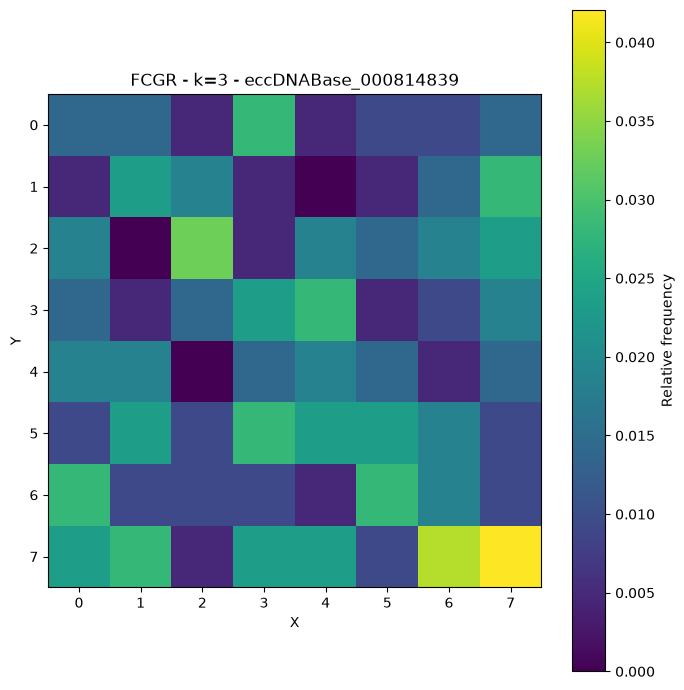

In [33]:
plt.figure(figsize=(7, 7))

plt.imshow(
    fcgr_3_norm,
    interpolation="nearest"
)

plt.title(
    f"FCGR - k=3 - {test_id}"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.colorbar(
    label="Relative frequency"
)

plt.tight_layout()
plt.show()

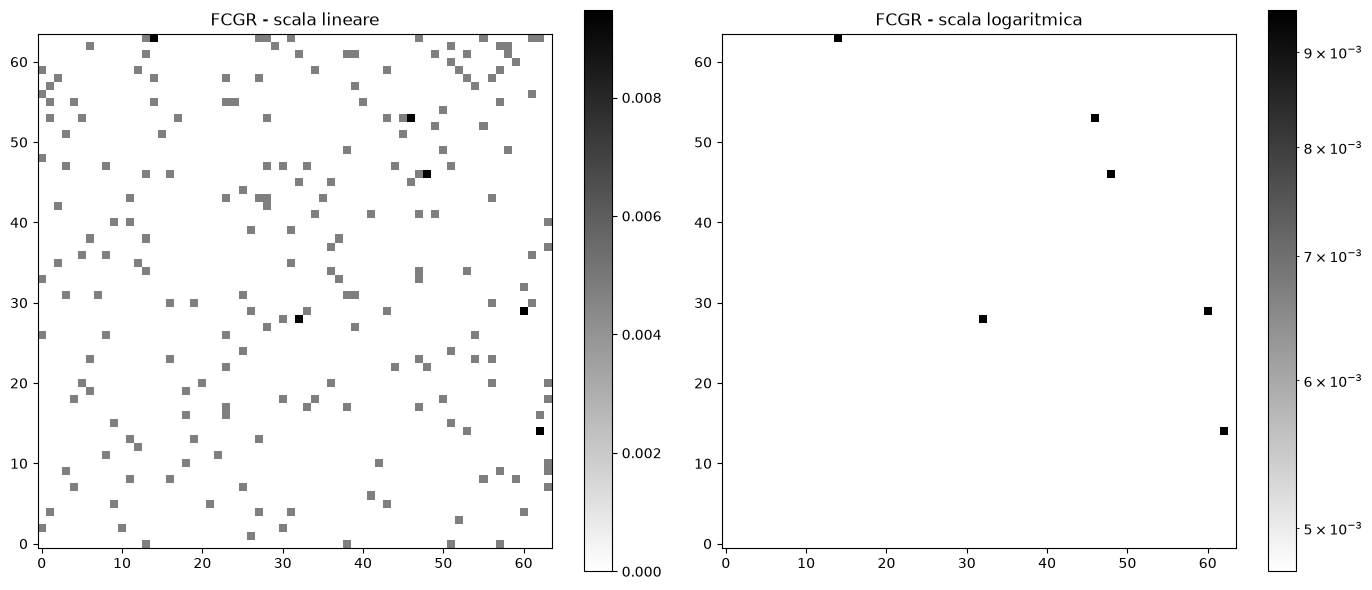

In [34]:
from matplotlib.colors import LogNorm

fcgr_counts, _, _ = compute_fcgr(
    test_sequence,
    k=6
)

fcgr_norm = normalize_fcgr(fcgr_counts)

positive_values = fcgr_norm[fcgr_norm > 0]

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# Lineare
im1 = axes[0].imshow(
    fcgr_norm,
    cmap="gray_r",
    origin="lower",
    interpolation="nearest"
)

axes[0].set_title("FCGR - scala lineare")

plt.colorbar(
    im1,
    ax=axes[0]
)

# Logaritmica
if len(positive_values) > 0:

    im2 = axes[1].imshow(
        fcgr_norm,
        cmap="gray_r",
        origin="lower",
        interpolation="nearest",
        norm=LogNorm(
            vmin=positive_values.min(),
            vmax=positive_values.max()
        )
    )

    axes[1].set_title("FCGR - scala logaritmica")

    plt.colorbar(
        im2,
        ax=axes[1]
    )

plt.tight_layout()
plt.show()

# Analisi delle FCGR per k = 3...10

Per valutare l'effetto della dimensione del k-mer, vengono generate FCGR con `k` compreso tra 3 e 10.

Per ogni sequenza e per ogni valore di `k` vengono registrati:

- dimensione della FCGR;
- numero di k-mer validi;
- numero di k-mer distinti;
- numero di celle non-zero;
- occupancy;
- sparsità;
- somma delle frequenze normalizzate.

In [35]:
K_VALUES = range(3, 11)

fcgr_results = []

In [36]:
for _, row in pilot_metadata.iterrows():

    seq_id = row["id"]
    disease = row["disease_clean"]

    sequence = pilot_sequences[seq_id]

    for k in K_VALUES:

        fcgr_counts, n_valid, n_distinct = (
            compute_fcgr(sequence, k)
        )

        total_cells = fcgr_counts.size

        non_zero = np.count_nonzero(
            fcgr_counts
        )

        occupancy = (
            non_zero
            / total_cells
            * 100
        )

        sparsity = 100 - occupancy

        fcgr_norm = normalize_fcgr(
            fcgr_counts
        )

        fcgr_results.append({

            "id": seq_id,

            "disease": disease,

            "k": k,

            "sequence_length": len(sequence),

            "fcgr_size": 2 ** k,

            "total_cells": total_cells,

            "valid_kmers": n_valid,

            "distinct_kmers": n_distinct,

            "non_zero_cells": non_zero,

            "occupancy_%": occupancy,

            "sparsity_%": sparsity,

            "normalized_sum": fcgr_norm.sum()
        })

In [37]:
fcgr_results = pd.DataFrame(
    fcgr_results
)

fcgr_results.head()

,id,disease,k,sequence_length,fcgr_size,total_cells,valid_kmers,distinct_kmers,non_zero_cells,occupancy_%,sparsity_%,normalized_sum
0,eccDNABase_000814839,healthy,3,216,8,64,214,61,61,95.312500,4.687500,1.0
1,eccDNABase_000814839,healthy,4,216,16,256,213,143,143,55.859375,44.140625,1.0
2,eccDNABase_000814839,healthy,5,216,32,1024,212,195,195,19.042969,80.957031,1.0
3,eccDNABase_000814839,healthy,6,216,64,4096,211,205,205,5.004883,94.995117,1.0
4,eccDNABase_000814839,healthy,7,216,128,16384,210,209,209,1.275635,98.724365,1.0


In [38]:
fcgr_summary = (
    fcgr_results
    .groupby("k")
    .agg({
        "fcgr_size": "first",
        "valid_kmers": "median",
        "distinct_kmers": "median",
        "non_zero_cells": "median",
        "occupancy_%": "median",
        "sparsity_%": "median",
        "normalized_sum": "median"
    })
    .reset_index()
)

fcgr_summary

,k,fcgr_size,valid_kmers,distinct_kmers,non_zero_cells,occupancy_%,sparsity_%,normalized_sum
0,3,8,692.0,63.0,63.0,98.437500,1.562500,1.0
1,4,16,691.0,205.0,205.0,80.078125,19.921875,1.0
2,5,32,690.0,410.0,410.0,40.039062,59.960938,1.0
3,6,64,689.0,565.0,565.0,13.793945,86.206055,1.0
4,7,128,688.0,638.0,638.0,3.894043,96.105957,1.0
5,8,256,687.0,666.0,666.0,1.016235,98.983765,1.0
6,9,512,686.0,678.0,678.0,0.258636,99.741364,1.0
7,10,1024,685.0,683.0,683.0,0.065136,99.934864,1.0


In [39]:
fcgr_results["normalized_sum"].describe()

count    2.000000e+02
mean     1.000000e+00
std      6.861048e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: normalized_sum, dtype: float64

Visualizzazione di una sequenza per ogni k

In [40]:
visual_id = pilot_metadata.iloc[0]["id"]

visual_sequence = pilot_sequences[
    visual_id
]

print(
    "ID:",
    visual_id
)

print(
    "Disease:",
    pilot_metadata.loc[
        pilot_metadata["id"] == visual_id,
        "disease_clean"
    ].iloc[0]
)

print(
    "Length:",
    len(visual_sequence)
)

ID: eccDNABase_000814839
Disease: healthy
Length: 216


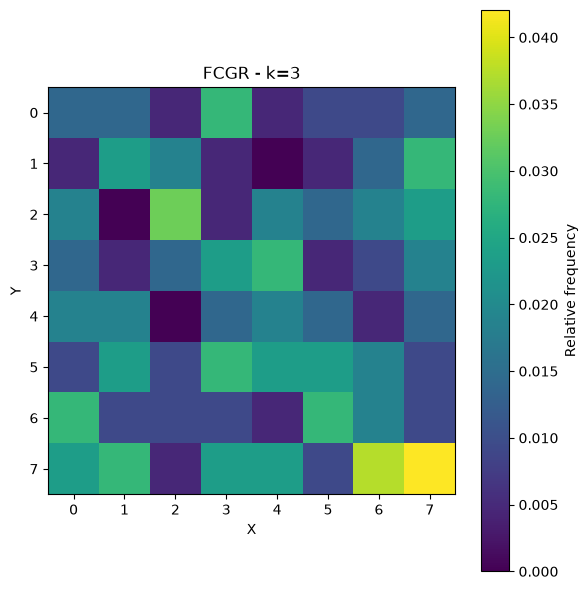

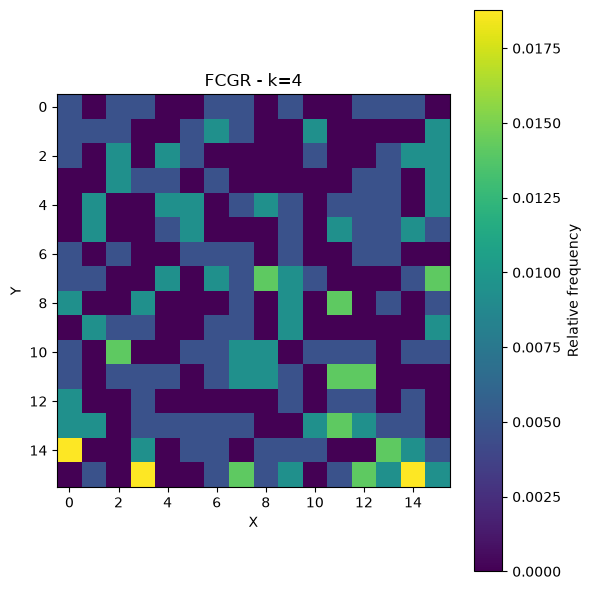

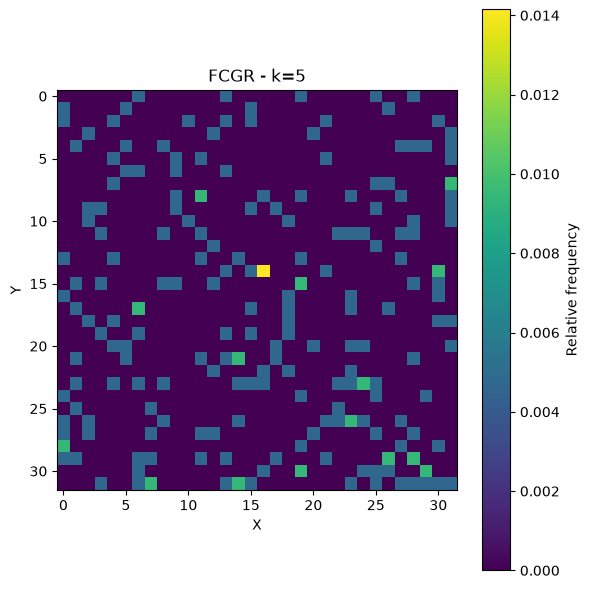

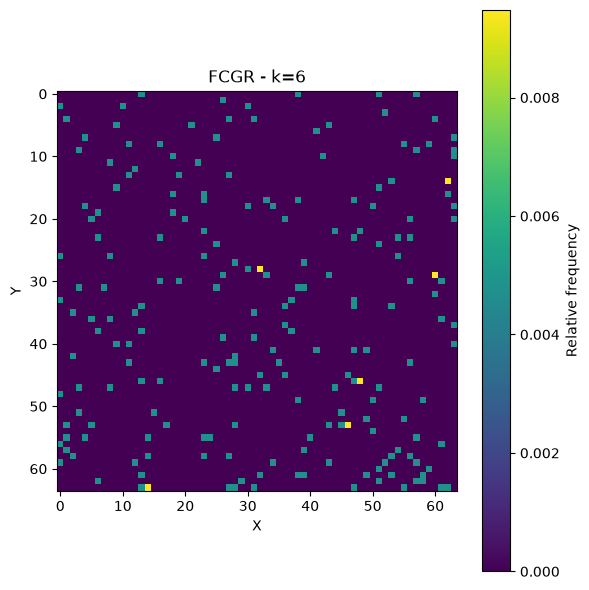

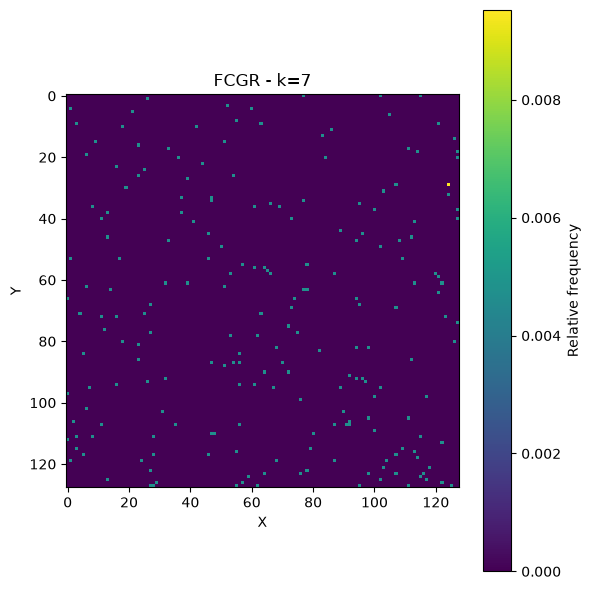

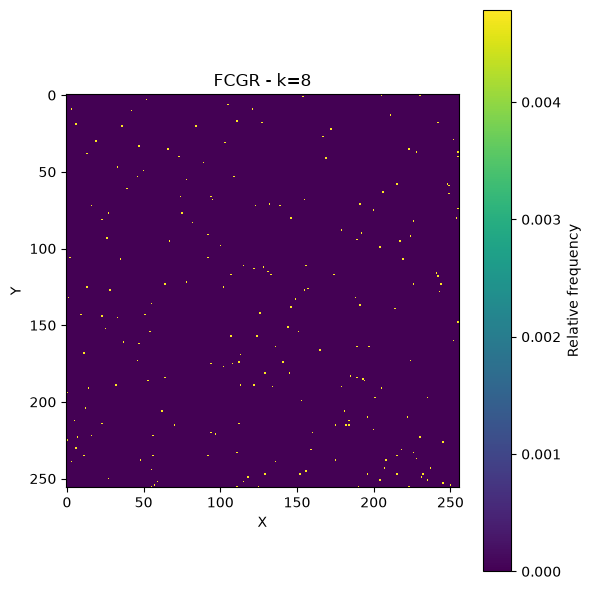

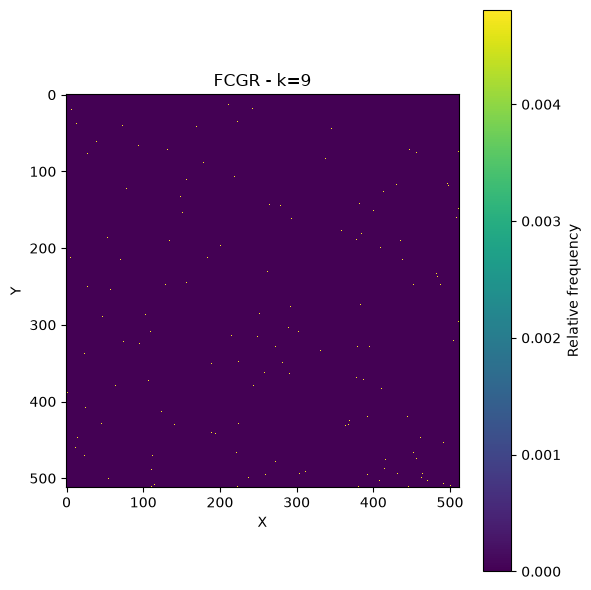

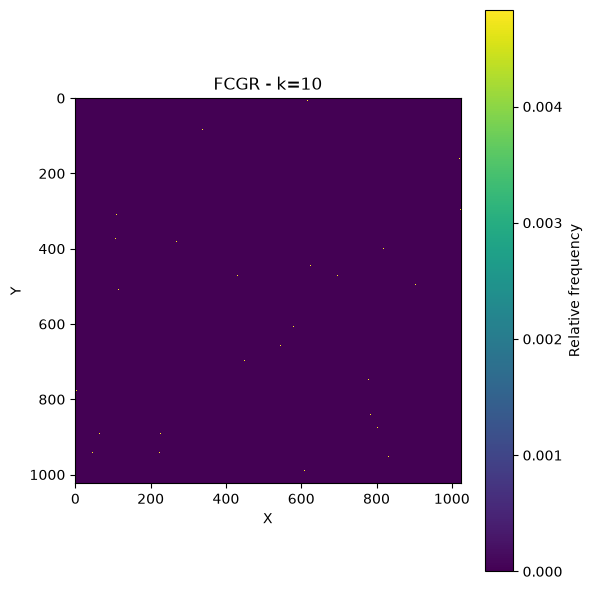

In [41]:
for k in K_VALUES:

    fcgr_counts, _, _ = compute_fcgr(
        visual_sequence,
        k
    )

    fcgr_norm = normalize_fcgr(
        fcgr_counts
    )

    plt.figure(figsize=(6, 6))

    plt.imshow(
        fcgr_norm,
        interpolation="nearest"
    )

    plt.title(
        f"FCGR - k={k}"
    )

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.colorbar(
        label="Relative frequency"
    )

    plt.tight_layout()
    plt.show()

Grafico delle sparsità

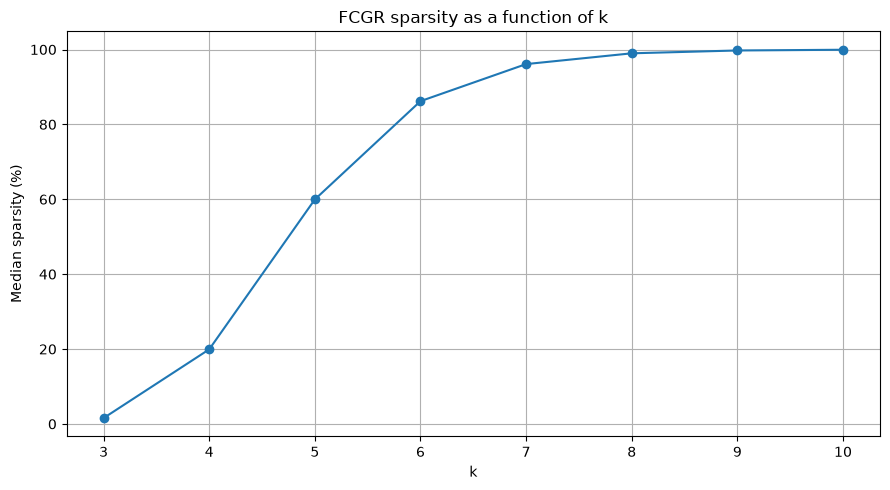

In [42]:
sparsity_by_k = (
    fcgr_results
    .groupby("k")["sparsity_%"]
    .median()
)

plt.figure(figsize=(9, 5))

plt.plot(
    sparsity_by_k.index,
    sparsity_by_k.values,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Median sparsity (%)")
plt.title(
    "FCGR sparsity as a function of k"
)

plt.xticks(list(K_VALUES))

plt.grid(True)

plt.tight_layout()
plt.show()

Grafico dei kmer distinti

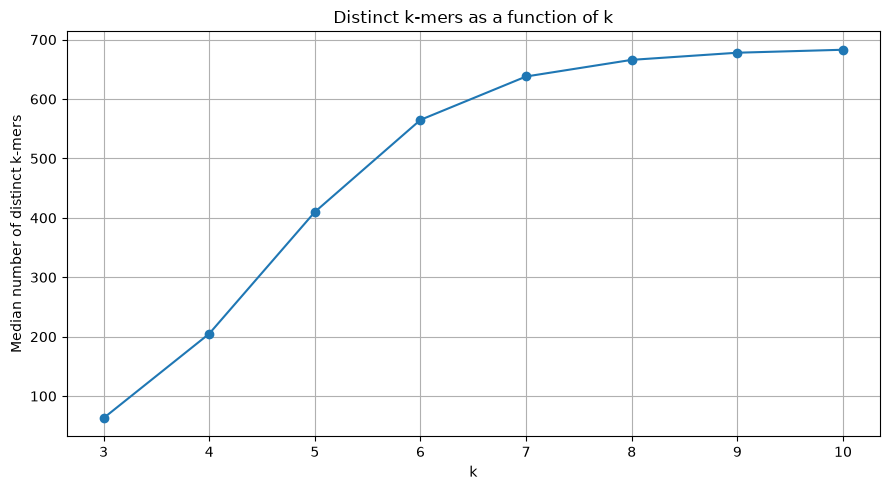

In [43]:
distinct_by_k = (
    fcgr_results
    .groupby("k")["distinct_kmers"]
    .median()
)

plt.figure(figsize=(9, 5))

plt.plot(
    distinct_by_k.index,
    distinct_by_k.values,
    marker="o"
)

plt.xlabel("k")
plt.ylabel(
    "Median number of distinct k-mers"
)

plt.title(
    "Distinct k-mers as a function of k"
)

plt.xticks(list(K_VALUES))

plt.grid(True)

plt.tight_layout()
plt.show()

Rapporto tra kmer distinti e possibili

In [44]:
occupancy_kmer = []

for k in K_VALUES:

    possible = 4 ** k

    observed = (
        fcgr_results.loc[
            fcgr_results["k"] == k,
            "distinct_kmers"
        ].median()
    )

    occupancy = (
        observed / possible * 100
    )

    occupancy_kmer.append({
        "k": k,
        "possible_kmers": possible,
        "median_distinct_kmers": observed,
        "occupancy_%": occupancy
    })

occupancy_kmer = pd.DataFrame(
    occupancy_kmer
)

occupancy_kmer

,k,possible_kmers,median_distinct_kmers,occupancy_%
0,3,64,63.0,98.437500
1,4,256,205.0,80.078125
2,5,1024,410.0,40.039062
3,6,4096,565.0,13.793945
4,7,16384,638.0,3.894043
5,8,65536,666.0,1.016235
6,9,262144,678.0,0.258636
7,10,1048576,683.0,0.065136


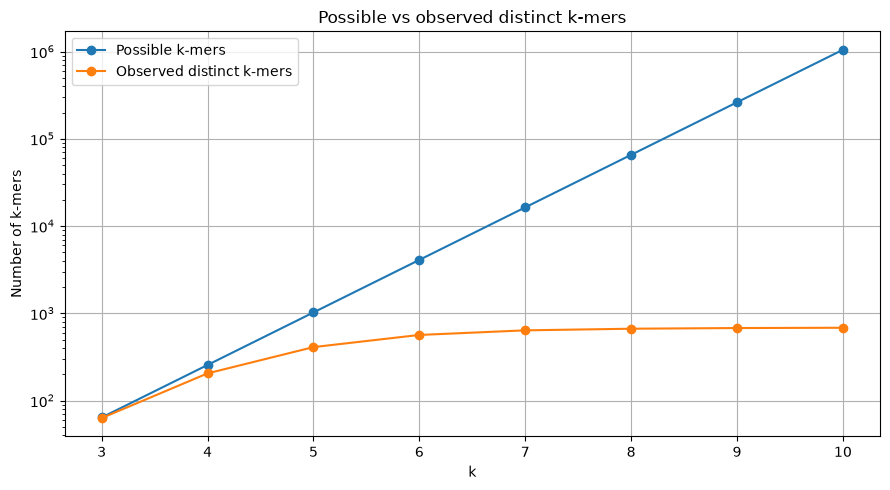

In [45]:
plt.figure(figsize=(9, 5))

plt.semilogy(
    occupancy_kmer["k"],
    occupancy_kmer["possible_kmers"],
    marker="o",
    label="Possible k-mers"
)

plt.semilogy(
    occupancy_kmer["k"],
    occupancy_kmer["median_distinct_kmers"],
    marker="o",
    label="Observed distinct k-mers"
)

plt.xlabel("k")
plt.ylabel("Number of k-mers")

plt.title(
    "Possible vs observed distinct k-mers"
)

plt.xticks(list(K_VALUES))

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

Osservazione: La generazione FCGR funziona fino a k=10, ma sulle sequenze eccDNA tipiche l'aumento di k produce una crescita molto rapida della sparsità. Nel pilot, k=10 arriva a circa il 99,93% di celle vuote e quasi tutti i 10-mer osservati sono unici. I valori intermedi, soprattutto k=5–7, sembrano al momento offrire un compromesso più interessante tra risoluzione e densità, ma la scelta va confermata su un campione più grande e stratificato per lunghezza.

Creazione classi di lunghezza

In [46]:
def assign_length_bin(length):
    if length < 300:
        return "short"
    elif length <= 1000:
        return "medium"
    else:
        return "long"

metadata["length_bin"] = metadata["length"].apply(assign_length_bin)

metadata["length_bin"].value_counts()

length_bin
medium    2151393
long      1126427
short      477259
Name: count, dtype: int64

Creazione pilot statistico più grande

In [47]:
PILOT_CLASSES = [
    "healthy",
    "gastric cancer",
    "ovarian cancer",
    "prostate cancer",
    "colorectal cancer"
]

N_PER_CLASS_LENGTH = 100
RANDOM_STATE = 42

In [48]:
pilot_parts = []

for disease in PILOT_CLASSES:

    for length_bin in ["short", "medium", "long"]:

        subset = metadata[
            (metadata["disease_clean"] == disease) &
            (metadata["length_bin"] == length_bin)
        ]

        if len(subset) == 0:
            continue

        sampled = subset.sample(
            n=min(N_PER_CLASS_LENGTH, len(subset)),
            random_state=RANDOM_STATE
        )

        pilot_parts.append(sampled)

pilot_large = pd.concat(
    pilot_parts,
    ignore_index=True
)

print("Numero sequenze pilot:", len(pilot_large))

pd.crosstab(
    pilot_large["disease_clean"],
    pilot_large["length_bin"]
)

Numero sequenze pilot: 1500


length_bin,long,medium,short
disease_clean,,,
colorectal cancer,100,100,100
gastric cancer,100,100,100
healthy,100,100,100
ovarian cancer,100,100,100
prostate cancer,100,100,100


Recupero sequenze dal fasta

In [49]:
pilot_large_ids = pilot_large["id"].astype(str).tolist()

pilot_large_sequences = load_fasta_sequences(
    FASTA_PATH,
    pilot_large_ids
)

print("Sequenze richieste:", len(pilot_large_ids))
print("Sequenze trovate:", len(pilot_large_sequences))

Sequenze richieste: 1500
Sequenze trovate: 1500


In [50]:
missing_ids = (
    set(pilot_large_ids)
    - set(pilot_large_sequences.keys())
)

print("Sequenze mancanti:", len(missing_ids))

Sequenze mancanti: 0


In [51]:
K_VALUES = range(3, 11)

fcgr_large_results = []

In [52]:
for _, row in pilot_large.iterrows():

    seq_id = row["id"]
    disease = row["disease_clean"]
    length_bin = row["length_bin"]

    sequence = pilot_large_sequences[seq_id]

    for k in K_VALUES:

        fcgr_counts, n_valid, n_distinct = compute_fcgr(
            sequence,
            k
        )

        total_cells = fcgr_counts.size
        non_zero = np.count_nonzero(fcgr_counts)

        occupancy = (
            non_zero / total_cells * 100
        )

        sparsity = 100 - occupancy

        if n_valid > 0:
            unique_ratio = n_distinct / n_valid
        else:
            unique_ratio = np.nan

        fcgr_large_results.append({
            "id": seq_id,
            "disease": disease,
            "length_bin": length_bin,
            "sequence_length": len(sequence),
            "k": k,
            "fcgr_size": 2 ** k,
            "valid_kmers": n_valid,
            "distinct_kmers": n_distinct,
            "unique_ratio": unique_ratio,
            "occupancy_%": occupancy,
            "sparsity_%": sparsity
        })

In [53]:
fcgr_large_results = pd.DataFrame(
    fcgr_large_results
)

fcgr_large_results.head()

,id,disease,length_bin,sequence_length,k,fcgr_size,valid_kmers,distinct_kmers,unique_ratio,occupancy_%,sparsity_%
0,CircleBaseV2_002803814,healthy,short,101,3,8,99,48,0.484848,75.000000,25.000000
1,CircleBaseV2_002803814,healthy,short,101,4,16,98,79,0.806122,30.859375,69.140625
2,CircleBaseV2_002803814,healthy,short,101,5,32,97,94,0.969072,9.179688,90.820312
3,CircleBaseV2_002803814,healthy,short,101,6,64,96,96,1.000000,2.343750,97.656250
4,CircleBaseV2_002803814,healthy,short,101,7,128,95,95,1.000000,0.579834,99.420166


Analisi globale per k

In [54]:
summary_by_k = (
    fcgr_large_results
    .groupby("k")
    .agg(
        n_sequences=("id", "count"),

        median_length=("sequence_length", "median"),

        median_valid_kmers=("valid_kmers", "median"),

        median_distinct_kmers=("distinct_kmers", "median"),

        median_unique_ratio=("unique_ratio", "median"),

        median_occupancy=("occupancy_%", "median"),

        q25_occupancy=("occupancy_%", lambda x: x.quantile(0.25)),

        q75_occupancy=("occupancy_%", lambda x: x.quantile(0.75)),

        median_sparsity=("sparsity_%", "median")
    )
    .reset_index()
)

summary_by_k

,k,n_sequences,median_length,median_valid_kmers,median_distinct_kmers,median_unique_ratio,median_occupancy,q25_occupancy,q75_occupancy,median_sparsity
0,3,1500,505.5,503.5,62.0,0.121327,96.875000,89.062500,100.000000,3.125000
1,4,1500,505.5,502.5,186.0,0.359132,72.656250,51.171875,89.062500,27.343750
2,5,1500,505.5,501.5,329.5,0.674735,32.177734,18.334961,57.128906,67.822266
3,6,1500,505.5,500.5,422.5,0.863454,10.314941,5.126953,22.216797,89.685059
4,7,1500,505.5,499.5,457.5,0.946429,2.792358,1.322937,6.506348,97.207642
5,8,1500,505.5,498.5,472.0,0.979788,0.720215,0.335312,1.728058,99.279785
6,9,1500,505.5,497.5,482.0,0.992562,0.183868,0.083828,0.439930,99.816132
7,10,1500,505.5,496.5,482.0,0.997480,0.045967,0.020862,0.110483,99.954033


Analisi per fascia di lunghezza

In [55]:
summary_by_length_k = (
    fcgr_large_results
    .groupby(
        ["length_bin", "k"]
    )
    .agg(
        n=("id", "count"),
        median_length=("sequence_length", "median"),
        median_distinct=("distinct_kmers", "median"),
        median_unique_ratio=("unique_ratio", "median"),
        median_occupancy=("occupancy_%", "median"),
        median_sparsity=("sparsity_%", "median")
    )
    .reset_index()
)

summary_by_length_k

,length_bin,k,n,median_length,median_distinct,median_unique_ratio,median_occupancy,median_sparsity
0,long,3,500,1503.5,64.0,0.042335,100.000000,0.000000
1,long,4,500,1503.5,238.0,0.156301,92.968750,7.031250
2,long,5,500,1503.5,653.0,0.428846,63.769531,36.230469
3,long,6,500,1503.5,1096.5,0.725366,26.770020,73.229980
4,long,7,500,1503.5,1331.5,0.894096,8.126831,91.873169
5,long,8,500,1503.5,1419.5,0.957848,2.165985,97.834015
6,long,9,500,1503.5,1447.5,0.981395,0.552177,99.447823
7,long,10,500,1503.5,1455.5,0.991012,0.138807,99.861193
8,medium,3,500,505.5,62.0,0.123792,96.875000,3.125000
9,medium,4,500,505.5,186.0,0.371157,72.656250,27.343750


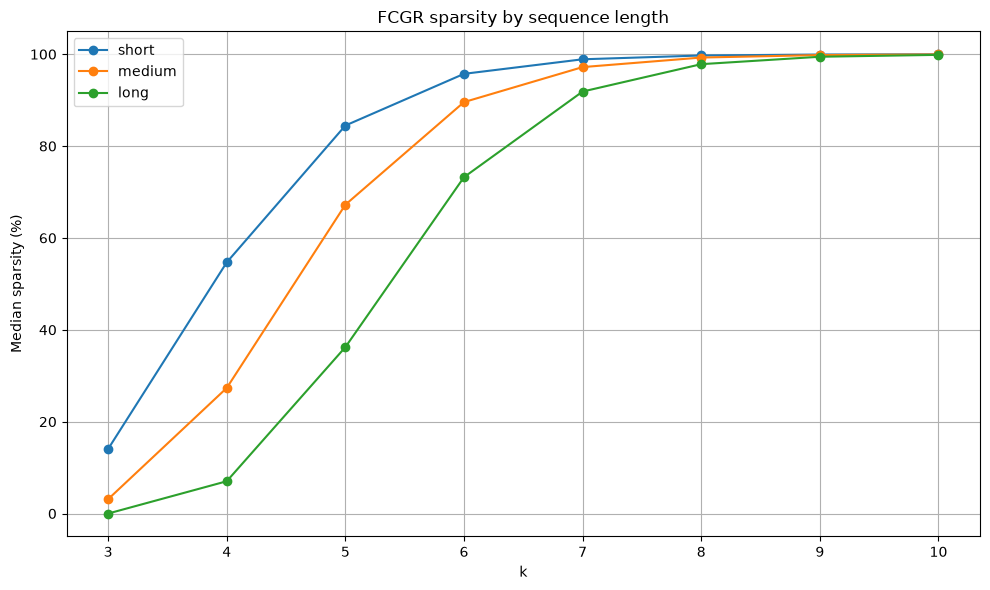

In [56]:
plt.figure(figsize=(10, 6))

for length_bin in ["short", "medium", "long"]:

    subset = summary_by_length_k[
        summary_by_length_k["length_bin"]
        == length_bin
    ]

    plt.plot(
        subset["k"],
        subset["median_sparsity"],
        marker="o",
        label=length_bin
    )

plt.xlabel("k")
plt.ylabel("Median sparsity (%)")
plt.title("FCGR sparsity by sequence length")
plt.xticks(list(K_VALUES))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Grafico unique ratio

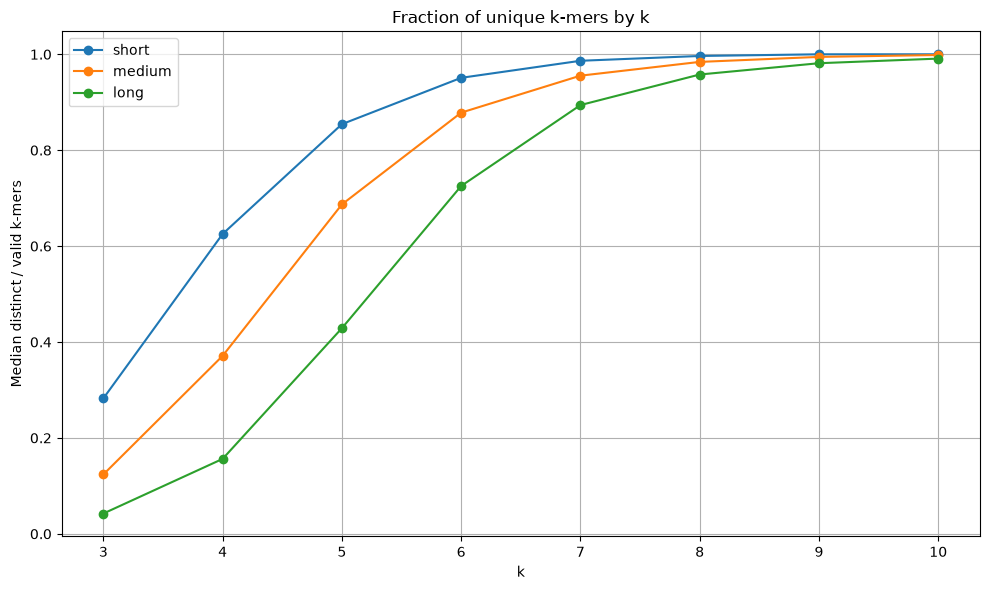

In [57]:
plt.figure(figsize=(10, 6))

for length_bin in ["short", "medium", "long"]:

    subset = summary_by_length_k[
        summary_by_length_k["length_bin"]
        == length_bin
    ]

    plt.plot(
        subset["k"],
        subset["median_unique_ratio"],
        marker="o",
        label=length_bin
    )

plt.xlabel("k")
plt.ylabel("Median distinct / valid k-mers")
plt.title("Fraction of unique k-mers by k")
plt.xticks(list(K_VALUES))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Boxplot della sparsità

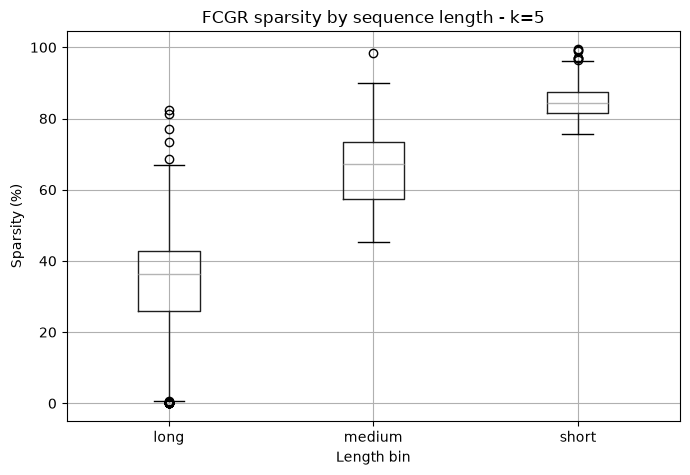

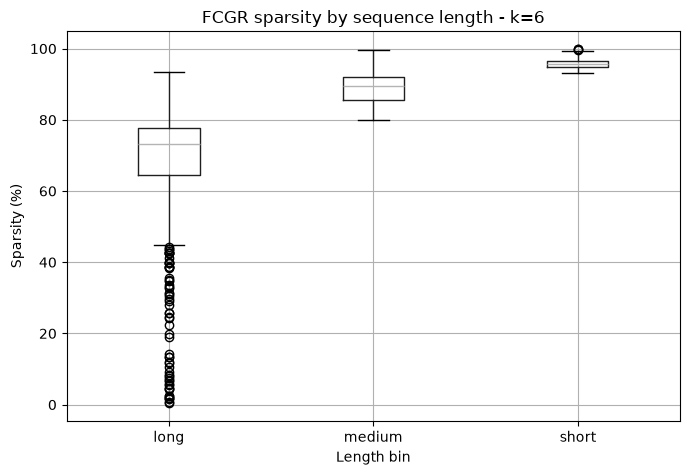

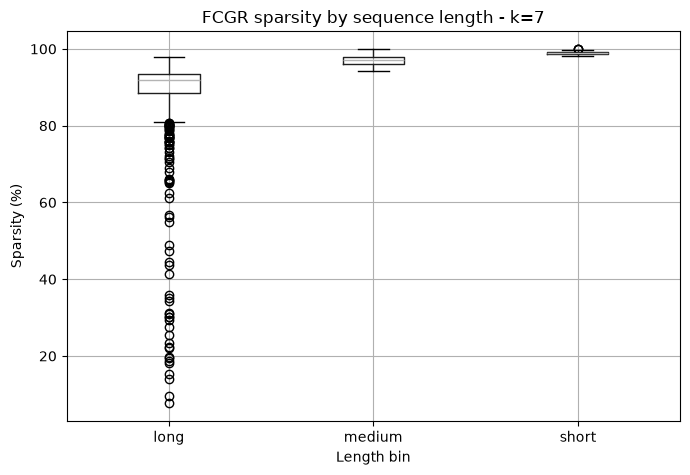

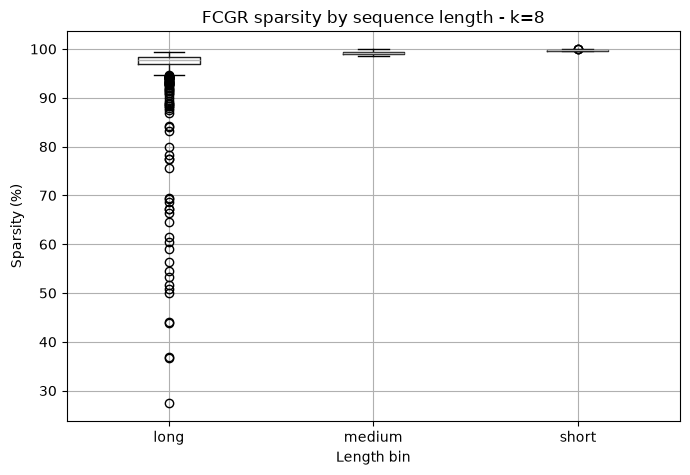

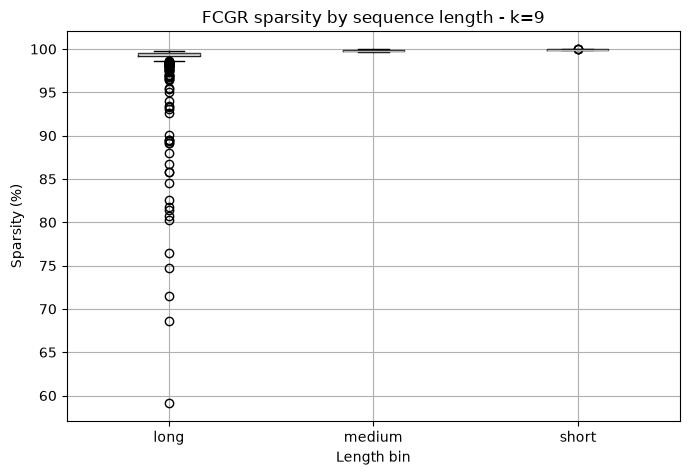

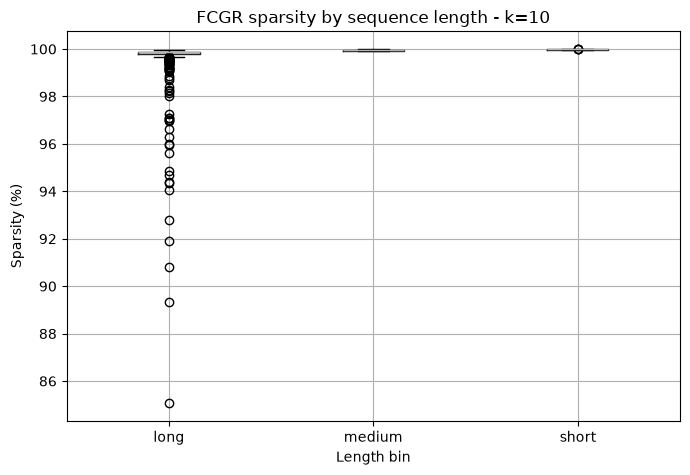

In [58]:
for k in [5, 6, 7, 8, 9, 10]:

    data_k = fcgr_large_results[
        fcgr_large_results["k"] == k
    ]

    data_k.boxplot(
        column="sparsity_%",
        by="length_bin",
        figsize=(7, 5)
    )

    plt.title(
        f"FCGR sparsity by sequence length - k={k}"
    )

    plt.suptitle("")
    plt.xlabel("Length bin")
    plt.ylabel("Sparsity (%)")

    plt.tight_layout()
    plt.show()

Memoria teorica

In [59]:
memory_rows = []

for k in K_VALUES:

    size = 2 ** k
    cells = size * size

    bytes_float32 = cells * 4

    memory_rows.append({
        "k": k,
        "fcgr_shape": f"{size}x{size}",
        "cells": cells,
        "memory_float32_MB":
            bytes_float32 / (1024 ** 2)
    })

memory_by_k = pd.DataFrame(memory_rows)

memory_by_k

,k,fcgr_shape,cells,memory_float32_MB
0,3,8x8,64,0.000244
1,4,16x16,256,0.000977
2,5,32x32,1024,0.003906
3,6,64x64,4096,0.015625
4,7,128x128,16384,0.062500
5,8,256x256,65536,0.250000
6,9,512x512,262144,1.000000
7,10,1024x1024,1048576,4.000000


Verifica sparsità per disease

In [60]:
summary_by_disease_k = (
    fcgr_large_results
    .groupby(
        ["disease", "k"]
    )
    .agg(
        median_length=("sequence_length", "median"),
        median_sparsity=("sparsity_%", "median"),
        median_unique_ratio=("unique_ratio", "median")
    )
    .reset_index()
)

summary_by_disease_k

,disease,k,median_length,median_sparsity,median_unique_ratio
0,colorectal cancer,3,589.5,1.562500,0.104648
1,colorectal cancer,4,589.5,23.242188,0.327532
2,colorectal cancer,5,589.5,62.158203,0.642663
3,colorectal cancer,6,589.5,87.414551,0.851774
4,colorectal cancer,7,589.5,96.591187,0.940212
5,colorectal cancer,8,589.5,99.130249,0.978963
6,colorectal cancer,9,589.5,99.781036,0.991679
7,colorectal cancer,10,589.5,99.945116,0.997286
8,gastric cancer,3,671.5,4.687500,0.091224
9,gastric cancer,4,671.5,21.093750,0.305992


Tabella finale sintetica

In [61]:
final_k_summary = summary_by_k.merge(
    memory_by_k[
        ["k", "fcgr_shape", "memory_float32_MB"]
    ],
    on="k",
    how="left"
)

final_k_summary = final_k_summary[
    [
        "k",
        "fcgr_shape",
        "median_distinct_kmers",
        "median_unique_ratio",
        "median_occupancy",
        "median_sparsity",
        "memory_float32_MB"
    ]
]

final_k_summary

,k,fcgr_shape,median_distinct_kmers,median_unique_ratio,median_occupancy,median_sparsity,memory_float32_MB
0,3,8x8,62.0,0.121327,96.875000,3.125000,0.000244
1,4,16x16,186.0,0.359132,72.656250,27.343750,0.000977
2,5,32x32,329.5,0.674735,32.177734,67.822266,0.003906
3,6,64x64,422.5,0.863454,10.314941,89.685059,0.015625
4,7,128x128,457.5,0.946429,2.792358,97.207642,0.062500
5,8,256x256,472.0,0.979788,0.720215,99.279785,0.250000
6,9,512x512,482.0,0.992562,0.183868,99.816132,1.000000
7,10,1024x1024,482.0,0.997480,0.045967,99.954033,4.000000


In [62]:
def classify_k(row):

    k = row["k"]

    if k <= 4:
        return "Very dense / low resolution"

    elif k == 5:
        return "Good candidate"

    elif k == 6:
        return "Good candidate"

    elif k == 7:
        return "Experimental candidate"

    else:
        return "Too sparse for first model"


final_k_summary["interpretation"] = (
    final_k_summary.apply(
        classify_k,
        axis=1
    )
)

final_k_summary

,k,fcgr_shape,median_distinct_kmers,median_unique_ratio,median_occupancy,median_sparsity,memory_float32_MB,interpretation
0,3,8x8,62.0,0.121327,96.875000,3.125000,0.000244,Very dense / low resolution
1,4,16x16,186.0,0.359132,72.656250,27.343750,0.000977,Very dense / low resolution
2,5,32x32,329.5,0.674735,32.177734,67.822266,0.003906,Good candidate
3,6,64x64,422.5,0.863454,10.314941,89.685059,0.015625,Good candidate
4,7,128x128,457.5,0.946429,2.792358,97.207642,0.062500,Experimental candidate
5,8,256x256,472.0,0.979788,0.720215,99.279785,0.250000,Too sparse for first model
6,9,512x512,482.0,0.992562,0.183868,99.816132,1.000000,Too sparse for first model
7,10,1024x1024,482.0,0.997480,0.045967,99.954033,4.000000,Too sparse for first model


Salvataggio risultati

In [63]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "fcgr_analysis"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Results directory:")
print(RESULTS_DIR)

Results directory:
..\results\fcgr_analysis


In [64]:
summary_by_k.to_csv(
    RESULTS_DIR / "summary_by_k.csv",
    index=False
)

summary_by_length_k.to_csv(
    RESULTS_DIR / "summary_by_length_k.csv",
    index=False
)

memory_by_k.to_csv(
    RESULTS_DIR / "memory_by_k.csv",
    index=False
)

final_k_summary.to_csv(
    RESULTS_DIR / "final_k_summary.csv",
    index=False
)

print("FCGR analysis results saved.")

FCGR analysis results saved.


In [65]:
fcgr_large_results.to_csv(
    RESULTS_DIR / "fcgr_pilot_results.csv",
    index=False
)

In [66]:
candidate_k_summary = (
    summary_by_length_k[
        summary_by_length_k["k"].isin(
            [5, 6, 7]
        )
    ]
    .copy()
)

candidate_k_summary[
    [
        "length_bin",
        "k",
        "median_length",
        "median_distinct",
        "median_unique_ratio",
        "median_occupancy",
        "median_sparsity"
    ]
]

,length_bin,k,median_length,median_distinct,median_unique_ratio,median_occupancy,median_sparsity
2,long,5,1503.5,653.0,0.428846,63.769531,36.230469
3,long,6,1503.5,1096.5,0.725366,26.770020,73.229980
4,long,7,1503.5,1331.5,0.894096,8.126831,91.873169
10,medium,5,505.5,335.5,0.686955,32.763672,67.236328
11,medium,6,505.5,427.0,0.878358,10.424805,89.575195
12,medium,7,505.5,459.5,0.955423,2.804565,97.195435
18,short,5,191.0,159.0,0.854290,15.527344,84.472656
19,short,6,191.0,175.0,0.950949,4.272461,95.727539
20,short,7,191.0,181.0,0.986486,1.104736,98.895264


In [67]:
candidate_k_summary.to_csv(
    RESULTS_DIR / "candidate_k_by_length.csv",
    index=False
)

# Conclusioni della fase 2 — Analisi FCGR e scelta dei k-mer

In questa fase è stata implementata e validata la pipeline per la generazione delle Frequency Chaos Game Representations (FCGR) a partire dalle sequenze eccDNA.

Le sequenze sono state recuperate dal file FASTA utilizzando gli identificativi presenti nei metadati e la corrispondenza tra TSV e FASTA è stata verificata con successo. La funzione FCGR utilizza la convenzione CGR iterativa già adottata nel precedente progetto di esempio, mantenendo quindi una rappresentazione spaziale coerente dei k-mer.

Le FCGR sono state generate per valori di `k` compresi tra 3 e 10. Per ogni matrice sono stati analizzati il numero di k-mer validi, il numero di k-mer distinti, l'occupancy, la sparsità e il rapporto tra k-mer distinti e k-mer totali (`unique_ratio`). Le matrici sono state inoltre normalizzate in frequenza relativa, in modo da ridurre la dipendenza diretta dei conteggi dalla lunghezza della sequenza.

Una prima analisi pilota è stata successivamente estesa a un campione di 1500 sequenze, bilanciato tra cinque classi biologiche e tre fasce di lunghezza (`short`, `medium`, `long`). Questo ha permesso di studiare in modo più robusto la relazione tra dimensione del k-mer, lunghezza della sequenza e sparsità della rappresentazione.

I risultati mostrano un aumento molto rapido della sparsità all'aumentare di `k`. Per valori bassi (`k=3` e `k=4`) le matrici risultano molto dense e descrivono principalmente pattern composizionali generali. `k=5` rappresenta un primo compromesso tra risoluzione e densità della rappresentazione, mentre `k=6` introduce una maggiore specificità mantenendo ancora una quantità significativa di informazione distribuita nella matrice.

A partire da `k=7` le FCGR diventano fortemente sparse, soprattutto per le sequenze corte. Per `k=8`, `k=9` e `k=10` la percentuale di celle vuote si avvicina progressivamente al 100%. Parallelamente, il valore di `unique_ratio` tende a 1, indicando che per valori elevati di `k` quasi tutti i k-mer osservati compaiono una sola volta. In questo regime la FCGR perde quindi gran parte della componente di frequenza e tende a comportarsi come una rappresentazione di presenza/assenza dei k-mer.

L'analisi per fascia di lunghezza ha mostrato inoltre che la scelta di `k` non può essere completamente indipendente dalla lunghezza della sequenza. Le sequenze corte raggiungono livelli elevati di sparsità già per valori relativamente bassi di `k`, mentre le sequenze più lunghe mantengono una rappresentazione più densa anche per k-mer più grandi.

È stato infine valutato il costo computazionale delle diverse rappresentazioni. La dimensione della FCGR cresce esponenzialmente con `k`: da `32×32` per `k=5` fino a `1024×1024` per `k=10`. Le rappresentazioni con `k=9` e `k=10` risultano quindi contemporaneamente molto sparse e molto più costose in termini di memoria, rendendole poco efficienti come prima scelta per il training su larga scala.

## Scelta dei k candidati

Sulla base dei risultati ottenuti sono stati selezionati tre valori da portare alla fase di modellazione:

* **k = 5**: candidato principale, grazie al buon compromesso tra densità, informazione composizionale e costo computazionale;
* **k = 6**: candidato principale, con maggiore specificità rispetto a `k=5` e dimensione ancora facilmente gestibile;
* **k = 7**: candidato sperimentale, più sparso ma potenzialmente in grado di catturare pattern di sequenza più specifici.

I valori `k >= 8` non vengono scelti come input principale della prima rete Siamese a causa dell'elevata sparsità e del maggiore costo computazionale. Tuttavia, il loro comportamento è stato comunque analizzato fino a `k=10`, come previsto dagli obiettivi sperimentali della fase.

La scelta definitiva tra `k=5`, `k=6` e `k=7` verrà verificata sperimentalmente confrontando le performance della stessa architettura Siamese utilizzando le tre diverse rappresentazioni FCGR.

La fase successiva sarà quindi dedicata alla costruzione del dataset per la rete Siamese, generando coppie positive e negative separatamente all'interno degli split `train`, `validation` e `test`, in modo da evitare leakage tra gli insiemi.
